# Measuring a person tracker on MOT17

This notebook does one thing: it turns "the pipeline seems to work" into a
number that someone else can check.

The pipeline in this repository detects people frame by frame and follows them
across frames. Before this notebook existed, it reported counts that nobody
could verify — on one clip it reported anywhere between 95 and 483 unique
people depending on parameters, with no way to say which was right.

[MOT17](https://motchallenge.net) fixes that. It is a public benchmark of
pedestrian videos where every person in every frame has been annotated by hand
with a box **and a persistent identity**. That second part is what makes
tracking measurable rather than merely plausible.

**What you need before running this**

1. `MOT17.zip` (5.6 GB) from motchallenge.net, unzipped to `./MOT17`
2. `./scripts/setup_trackeval.sh` — fetches the official metric implementation
3. `pip install -r requirements.txt`

Nothing here re-implements a metric. Scoring goes through
[TrackEval](https://github.com/JonathonLuiten/TrackEval), the implementation
behind the public leaderboard.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from humandetect import mot17
from humandetect.benchmark import BenchmarkConfig, evaluate, run

print("ready")

ready


## 1. Trust the data before trusting the numbers

The dataset is 5.6 GB and not in version control, so nothing in this repository
can prove the copy on disk is intact. `mot17.verify()` checks it: that every
sequence folder exists, that the frame count on disk matches what each
`seqinfo.ini` declares, that frame numbering is contiguous, that every
ground-truth row parses with in-range values, and that no track id appears
twice in the same frame.

That last check matters more than it sounds. A repeated id in one frame would
make the ground-truth identity assignment ambiguous, and the identity metric
below depends on it being unambiguous.

In [2]:
stats = mot17.verify()
scenes = [s for s in stats["train"] if s.name.endswith("-FRCNN")]

print(f"{'scene':<14}{'frames':>8}{'resolution':>12}{'gt rows':>10}{'evaluated':>11}{'ids':>6}")
for s in scenes:
    print(f"{s.name.replace('-FRCNN', ''):<14}{s.length:>8}{s.resolution:>12}"
          f"{s.gt_rows:>10}{s.gt_evaluated:>11}{s.gt_ids:>6}")

total_frames = sum(s.length for s in scenes)
total_rows = sum(s.gt_rows for s in scenes)
total_eval = sum(s.gt_evaluated for s in scenes)
print(f"\n{total_frames} frames, {total_eval} evaluated pedestrian boxes, "
      f"{sum(s.gt_ids for s in scenes)} identities")

scene           frames  resolution   gt rows  evaluated   ids
MOT17-02           600   1920x1080     30003      18581    62
MOT17-04          1050   1920x1080    108005      47557    83
MOT17-05           837     640x480      8013       6917   133
MOT17-09           525   1920x1080     10411       5325    26
MOT17-10           654   1920x1080     17450      12839    57
MOT17-11           900   1920x1080     10617       9436    75
MOT17-13           750   1920x1080     20202      11642   110

5316 frames, 112297 evaluated pedestrian boxes, 546 identities


### The 21 folders are 7 videos

MOT17's train split has 21 sequence folders, and it is tempting to treat that as
21 sequences. It is not. It is 7 scenes, each duplicated once per *public
detector* (DPM, FRCNN, SDP). The frames and the ground truth are byte-identical
across the three copies — only the supplied detections differ.

Averaging a metric over all 21 folders therefore triple-counts 7 videos, and
produces a number that will not match anyone else's. `verify()` asserts the
three copies agree, which is what justifies scoring only the 7.

### Nearly half the annotations are not scored

Of the ground-truth rows above, only those with class 1 (`pedestrian`) and
confidence flag 1 are evaluated. The rest are **ignore regions**: bicycles,
cars, reflections, static persons, distractors. A detection landing on one of
those counts as neither a hit nor a false positive.

This is not a detail. Skip the filter and false positives inflate against
objects the benchmark deliberately declined to score — which is the single most
common reason a home-made evaluator disagrees with the official one.

In [3]:
from collections import Counter

combined = Counter()
for s in scenes:
    combined.update(s.class_counts)

dropped = total_rows - total_eval
print(f"{dropped} of {total_rows} rows ({100 * dropped / total_rows:.1f}%) are not evaluated\n")
for class_id, count in sorted(combined.items(), key=lambda kv: -kv[1]):
    marker = "  <- scored" if class_id == mot17.EVALUATED_CLASS else ""
    print(f"  class {class_id:>2}  {mot17.CLASS_NAMES[class_id]:<24}{count:>8}{marker}")

92404 of 204701 rows (45.1%) are not evaluated

  class  1  pedestrian                112297  <- scored
  class 10  occluder on ground         28573
  class 11  occluder full              19580
  class  4  bicycle                    13527
  class  7  static person              12041
  class  3  car                         6189
  class  9  occluder                    3724
  class  8  distractor                  3595
  class 12  reflection                  2250
  class  2  person on vehicle           1864
  class  5  motorbike                   1050
  class  6  non-motorised vehicle         11


## 2. What the three metrics actually measure

All three compare two partitions of boxes into identities — the tracker's and
the ground truth's. They differ in *when* they establish the correspondence,
and that choice is the whole story.

**MOTA** matches per frame, then counts events:

$$\mathrm{MOTA} = 1 - \frac{\mathrm{FN} + \mathrm{FP} + \mathrm{IDSW}}{|\mathrm{GT}|}$$

Because matching is local to each frame, an identity error is only visible at
the instant it happens. FN and FP number in the thousands while ID switches
number in the hundreds, so association is structurally underweighted. MOTA is
largely a detection metric. It can go negative.

**IDF1** inverts the order: one global assignment between ground-truth
trajectories and predicted trajectories over the whole sequence, then

$$\mathrm{IDF1} = \frac{2\,\mathrm{IDTP}}{2\,\mathrm{IDTP} + \mathrm{IDFP} + \mathrm{IDFN}}$$

Each ground-truth identity gets at most one predicted identity for all time, so
a track split in half loses roughly half its boxes however good those boxes are.

**HOTA** refuses the trade-off and factorises it:

$$\mathrm{HOTA}_\alpha = \sqrt{\mathrm{DetA}_\alpha \cdot \mathrm{AssA}_\alpha}$$

integrated over localisation thresholds $\alpha$. A geometric mean, so neither
factor can be sacrificed for the other — and because DetA and AssA are reported
separately, any change can be attributed to detection or to association instead
of guessed at. The rest of this notebook leans on that repeatedly.

## 3. A baseline worth beating

The original pipeline used SSD MobileNet v3 — a small convolutional detector
that runs through OpenCV's DNN module with no deep-learning framework
installed. Its input size is fixed at 320x320 by the frozen graph.

One scene first. MOT17-02 is 1920x1080, static camera, busy pedestrian street.

In [4]:
ssd = BenchmarkConfig(backend="ssd", confidence=0.5, min_frames=5)
run(["MOT17-02"], "nb-ssd", ssd)
ssd_result = evaluate("nb-ssd")

print()
print(ssd_result.table())
print()
print(ssd_result.summary())

backend=ssd imgsz=320 (fixed) confidence=0.5 min_frames=5 compensate=False

  MOT17-02-FRCNN     imgsz 1280   600 frames    6266 detections   54/62  tracks   30.2 fps
Error importing BURST due to missing underlying dependency: No module named 'pycocotools'

sequence                HOTA    DetA    AssA    IDF1    MOTA    MOTP
MOT17-02-FRCNN         11.21   11.06   11.54   11.60   -2.89   69.51
COMBINED               11.21   11.06   11.54   11.60   -2.89   69.51

Recall 14.8% (2743 of 18581 ground-truth boxes), precision 46.3% (3177 false positives).


Read the counts rather than the scores for a moment.

The failure is not mainly that the detector missed people — though it did. It
is that **more than half of what it emitted was not a person**. MOTP near 69
says the same thing from the other direction: even the boxes that did match were
loosely placed, and a box near the IoU 0.5 boundary is charged twice, once as a
false positive and once as a false negative.

MOTA is negative, which is worth stating plainly: on this sequence the tracker's
output is worse than emitting nothing at all.

## 4. Change one thing at a time

Two variables are worth separating: the **model** (SSD vs YOLOv8n) and the
**input resolution** (320 vs 640 vs 1280). Changing both at once would leave us
unable to attribute the difference to either.

A pedestrian 40 pixels tall in a 1080p frame is 13 pixels at an input size of
640, and 26 at 1280. Below roughly 16 pixels a detector of this class stops
finding them at all, so resolution is not a tuning knob here — it decides which
people are visible to the model in the first place.

In [5]:
runs = {}

for label, cfg in [
    ("yolo-640",  BenchmarkConfig(backend="yolo", imgsz=640,  confidence=0.5)),
    ("yolo-1280", BenchmarkConfig(backend="yolo", imgsz=1280, confidence=0.5)),
]:
    run(["MOT17-02"], f"nb-{label}", cfg, verbose=False)
    runs[label] = evaluate(f"nb-{label}")
    print(f"{label:<12} " + "  ".join(
        f"{k} {v:5.2f}" for k, v in runs[label].headline().items()))

yolo-640     HOTA 26.67  DetA 14.32  AssA 49.72  IDF1 24.60  MOTA 16.37  MOTP 83.75
yolo-1280    HOTA 28.57  DetA 19.33  AssA 42.42  IDF1 29.00  MOTA 22.19  MOTP 83.20


In [6]:
rows = [("ssd-320", ssd_result)] + list(runs.items())

print(f"{'run':<12}{'HOTA':>7}{'DetA':>7}{'AssA':>7}{'IDF1':>7}{'MOTA':>7}"
      f"{'TP':>7}{'FN':>7}{'FP':>7}{'IDSW':>6}")
for label, res in rows:
    h, c = res.headline(), res.counts()
    print(f"{label:<12}{h['HOTA']:>7.2f}{h['DetA']:>7.2f}{h['AssA']:>7.2f}"
          f"{h['IDF1']:>7.2f}{h['MOTA']:>7.2f}"
          f"{c['CLR_TP']:>7}{c['CLR_FN']:>7}{c['CLR_FP']:>7}{c['IDSW']:>6}")

run            HOTA   DetA   AssA   IDF1   MOTA     TP     FN     FP  IDSW
ssd-320       11.21  11.06  11.54  11.60  -2.89   2743  15838   3177   103
yolo-640      26.67  14.32  49.72  24.60  16.37   3143  15438     78    24
yolo-1280     28.57  19.33  42.42  29.00  22.19   4293  14288    122    47


### The result contradicted the hypothesis

Going from SSD at 320 to YOLOv8n at 640, recall barely moves. What collapses is
the false-positive count — roughly a fortyfold reduction. The baseline's problem
was overwhelmingly **precision**, not misses, and the prediction that resolution
would dominate via recall was wrong.

Resolution is real but secondary: 640 to 1280 is where recall actually improves,
at roughly half the throughput.

### And a genuinely counterintuitive effect

Watch AssA between the two YOLO rows. It goes **down** as the detector gets
better.

That is not noise. A better detector finds more people, more simultaneous
candidates means more opportunities to confuse two of them, and ID switches
rise accordingly. HOTA still improves because DetA gains more than AssA loses —
but a single MOTA number would have hidden the trade entirely. This is the
concrete argument for reporting the factors separately.

## 5. A defect the benchmark found

This repository applies its own duplicate suppression, because OpenCV's
`nmsThreshold` is a no-op with the SSD model. The rule drops any box that sits
at least 70% inside another — sound when the nested box is a second detection of
one person, which is the case it was validated against on a single-person test
image.

In a crowd it is not sound. A person standing behind another is *genuinely*
70%+ contained by them. The rule cannot distinguish the two cases.

In [7]:
# One field differs between these two configs. Containment is a fraction of
# the smaller box's area, so a threshold above 1.0 can never be reached and
# the containment half of the rule is effectively off.
base = BenchmarkConfig(backend="yolo", imgsz=1280, confidence=0.25)
off = BenchmarkConfig(backend="yolo", imgsz=1280, confidence=0.25, containment=1.01)

results = {}
for label, cfg in [("containment on", base), ("containment off", off)]:
    name = "nb-contain-on" if cfg.containment is None else "nb-contain-off"
    stats = run(["MOT17-02"], name, cfg, verbose=False)
    results[label] = (evaluate(name), stats[0])

for label, (res, stats) in results.items():
    h, c = res.headline(), res.counts()
    print(f"{label:<18}detections {stats.detections:>5}  HOTA {h['HOTA']:5.2f}  "
          f"DetA {h['DetA']:5.2f}  AssA {h['AssA']:5.2f}  "
          f"TP {c['CLR_TP']:>5}  FP {c['CLR_FP']:>5}")

on_dets = results["containment on"][1].detections
off_dets = results["containment off"][1].detections
print(f"\nSuppression removed {off_dets - on_dets} of {off_dets} detections "
      f"({100 * (off_dets - on_dets) / off_dets:.1f}%)")

containment on    detections  7578  HOTA 30.34  DetA 25.66  AssA 36.27  TP  6040  FP   734
containment off   detections  8454  HOTA 28.54  DetA 27.72  AssA 29.91  TP  6545  FP  1023

Suppression removed 876 of 8454 detections (10.4%)


Disabling the rule recovers several hundred true positives — real, distinct
people that the suppression was deleting. DetA rises and so does MOTA.

**But HOTA falls.** The recovered people are heavily occluded ones that appear
and vanish, so the tracker fragments on them and AssA drops further than DetA
gained. Detection improved; tracking got worse; the geometric mean went down.

Reporting MOTA alone here would have justified shipping a regression. The right
fix is neither on nor off — it is a rule that can tell a duplicate box from an
occluded neighbour, which is left as future work rather than pretended at.

## 6. The headline number

All seven scenes, best configuration: YOLOv8n, confidence 0.25, inference size
1280 **capped at each sequence's native resolution**.

That cap matters. MOT17-05 is 640x480, and running it at 1280 upscales past
native — inventing no detail but plenty of false positives, and costing that
sequence around 13 points of MOTA. The cap is a one-line fix for a mistake that
a per-sequence table made visible and a single combined number would have
buried.

In [8]:
full = evaluate("yolov8n-native-c25")

print(full.table())
print()
print(full.summary())

sequence                HOTA    DetA    AssA    IDF1    MOTA    MOTP
MOT17-02-FRCNN         30.34   25.66   36.27   35.35   27.99   80.84
MOT17-04-FRCNN         47.25   44.99   50.02   56.77   48.47   81.14
MOT17-05-FRCNN         42.90   43.64   42.39   56.74   48.97   76.02
MOT17-09-FRCNN         44.10   53.30   36.66   54.28   60.13   81.79
MOT17-10-FRCNN         36.64   42.45   32.04   47.92   46.74   74.82
MOT17-11-FRCNN         46.89   48.50   45.65   50.35   43.81   84.36
MOT17-13-FRCNN         32.95   34.52   32.13   40.26   36.78   75.51
COMBINED               41.99   41.07   43.45   50.32   43.87   79.79

Recall 52.8% (59342 of 112297 ground-truth boxes), precision 86.8% (9003 false positives).


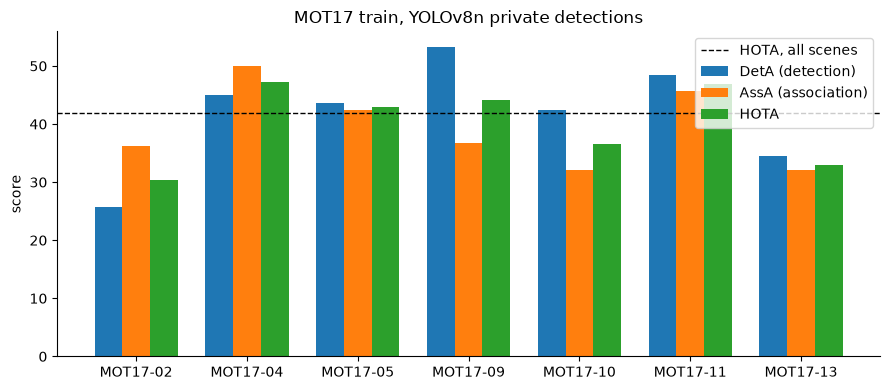

In [9]:
import matplotlib.pyplot as plt

labels = [s.replace("-FRCNN", "") for s in full.sequences]
hota = [full.score(("HOTA", "HOTA"), s) * 100 for s in full.sequences]
deta = [full.score(("HOTA", "DetA"), s) * 100 for s in full.sequences]
assa = [full.score(("HOTA", "AssA"), s) * 100 for s in full.sequences]

x = range(len(labels))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar([i - 0.25 for i in x], deta, 0.25, label="DetA (detection)")
ax.bar(list(x), assa, 0.25, label="AssA (association)")
ax.bar([i + 0.25 for i in x], hota, 0.25, label="HOTA")
ax.axhline(full.score(("HOTA", "HOTA")) * 100, ls="--", lw=1,
           color="k", label="HOTA, all scenes")
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel("score"); ax.set_title("MOT17 train, YOLOv8n private detections")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 7. What the numbers say to do next

**Association is now the binding constraint on the worst sequences.** The
scenes with the lowest HOTA are the ones with moving cameras, and they carry a
disproportionate share of all identity switches. Two things address that
directly, and both already exist in this repository or as a pretrained model:

1. **Camera-motion compensation** (`humandetect/motion.py`, `compensate=True`).
   Every run above left it off. On a moving camera a stationary person's box
   jumps between frames, overlap collapses, and the tracker mints a new identity
   from nothing.

2. **Appearance-based re-identification.** The tracker currently matches on
   geometry alone — IoU with a centroid-distance fallback. It has no notion of
   what a person *looks like*, so after a long occlusion it cannot recover an
   identity. A pretrained Re-ID network supplies exactly that, and IDF1 is the
   metric that would show whether it worked.

**Recall is the binding constraint everywhere else.** Roughly half of all
ground-truth boxes are still unmatched, concentrated in small distant
pedestrians. A larger YOLO variant, or tiling inference across the frame, both
target that.

Each is one variable with a before-and-after number. That is the point of
having done any of this: the next change can be argued about with evidence
rather than with adjectives.